Environment: velocity

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler
import scvelo
import IPython

In [2]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [3]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts_mm10.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]
print(adata_raw)

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [4]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

In [5]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_combined.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_reprogramming.csv", index_col=0)
mef_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mef.csv", index_col=0)
mesc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mesc.csv", index_col=0)
ipsc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_ipsc.csv", index_col=0)

In [6]:
# Function for plotting trends independent of trajectory

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="X", groups=None, columns=4, figure_width=14, plot_height=4, n_splines=6):
    """
    Plots smoothed gene expression using generalized additive models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    if f"{group_key}_colors" in adata.uns_keys():
        palette = adata.uns[f"{group_key}_colors"]
        color_map = dict(zip(unique_groups, palette))
    else:
        palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
        color_map = dict(zip(unique_groups, palette))


    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        if layer == "raw":
            expr_data = adata.raw.to_adata()[:, gene].X
        elif layer == "X":
            expr_data = adata[:, gene].X
        elif layer == "obs":
            expr_data = adata.obs[gene]
        else:
            expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        if hasattr(expr_data, "flatten"):
            expr_data = expr_data.flatten()
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            color = color_map[group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a spline term s(0)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=n_splines)).fit(X, y)
            
            # Greate grid
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot line
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot confidence interval
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend to the first plot
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

# Define colors for all three groups

group_colors = [
    "#cbc9ca",
    "#0a652c",
    "#da2e24",
    "#3180bd",
]

adata.uns["group_colors"] = group_colors

control_indices = adata.obs["group"] == "control"
hic2_indices = adata.obs["group"] == "Hic2"
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

# Identify ChipSeq targets of Hic2

In [7]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100).index.to_numpy()

In [8]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [9]:
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [10]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(shared_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

In [11]:
# Differentially expressed targets that are drivers of dead end

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
reprogramming_de.loc[de_dead_end_drivers].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Tlx2,585.037236,-1.107785,0.157145,-7.049422,1.796624e-12,2.177406e-11
Zbtb7c,1521.129230,-0.943320,0.058151,-16.221943,3.528526e-59,8.875744e-57


All dead end driver TFs that are targets of Hic2 are differentially expressed. Tlx2 is an interesting targets that have not been linked to reprogramming efficiency before. It is a clearer reprogramming driver in Hic2 OX than in control. Hoxa7 and Hmgb3 do not look like drivers in the Cellrank plot. Zbtb7 only looks like a driver in Hic2, and it has much higher expression in Hic2.

In [12]:
hic2_target_scores.loc["Dmrtc2"]

chip_score    0.775534
Name: Dmrtc2, dtype: float64

Dmtrc2 is not a Klf4 target, making it less consistent with the overall hypothesis. Cdh1 is not a Klf4 target.

In [13]:
# Differentially expressed targets that are drivers of stem cells

de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)
reprogramming_de.loc[de_stem_cell_drivers].sort_values("log2FoldChange", ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Zfp42,2688.373406,1.344900,0.149763,8.980156,2.703821e-19,6.666513e-18
Tcf7l1,582.207950,1.263931,0.164272,7.694150,1.424378e-14,2.177080e-13
Jarid2,2140.717811,0.820343,0.135571,6.051022,1.439299e-09,1.214135e-08
Rest,2085.826504,0.492894,0.113039,4.360393,1.298291e-05,6.121253e-05


All stem cell driver TFs that are targets of Hic2 except Klf2, Mycn and Tsc22d1 have differential expression.

In [14]:
# All of them are also targets of Klf4
numpy.intersect1d(de_stem_cell_drivers, klf4_targets)

array(['Jarid2', 'Rest', 'Tcf7l1', 'Zfp42'], dtype=object)

Other factors to consider:
- Better Cellrank analysis, such as correlation with states early in trajectory, or at least ignoring very late latent times to ignore what happens when cells become stem cells.
- Differential expression in important parts of the trajectory, such as the Day 4 Control macrostate.
- Enrichment of motifs among differentially expressed genes. 
- Public ChipSeq data
- Public perturbation followed by expression data

# Activity of transcription factor targets

In [15]:
# Investigate how Hic2 affects Klf4 expression

reduced_columns = ["Reprogramming LFC", "Reprogramming p adjusted", "MEF LFC", "MEF p adjusted", "mESC LFC", "mESC p adjusted",
                   "iPSC LFC", "iPSC p adjusted"]
bulk_de.loc["Klf4", reduced_columns]

Reprogramming LFC          -2.592896e-02
Reprogramming p adjusted    8.158653e-01
MEF LFC                    -8.392690e-01
MEF p adjusted              2.611282e-03
mESC LFC                    1.706289e+00
mESC p adjusted             3.082652e-24
iPSC LFC                   -4.795948e-01
iPSC p adjusted             9.998311e-01
Name: Klf4, dtype: float64

Hic2 OX decreased Klf4 expression in MEFs, but Hic2 KO decreased Klf4 expression in mESCs. Inconclusive, but since Hic2 is mainly a repressor a direct effect would probably be downregulation. The grouped trend plot suggests Klf4 is downregulated slightly by Hic2.

CollecTRI appears to be a useful database. Dorothea lacks many TFs such as Ovol1, Tlx2 and Hoxa7.

In [16]:
# Load CollecTRI database

collectri_df = decoupler.op.collectri(organism="mouse")

In [17]:
genes_of_interest = de_dead_end_drivers.tolist() + de_stem_cell_drivers.tolist() + ["Klf4", "Myc", "Hic2"]

In [18]:
# Targets of Myc

collectri_df.query("source == \"Myc\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
861,Myc,Myc,-1.0,ExTRI;HTRI;TFactS,10467407;10606235;10625678;10657901;10672043;1...,PMID
11396,Myc,Ovol1,1.0,ExTRI,16636146,default activation
14303,Myc,Klf4,1.0,ExTRI,19736564,default activation


In [19]:
# Targets of Klf4

collectri_df.query("source == \"Klf4\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
4817,Klf4,Klf4,1.0,ExTRI;NTNU.Curated,12087155;22337869;22854048,PMID
14302,Klf4,Myc,1.0,ExTRI;NTNU.Curated,17974960,default activation


In [20]:
# Targets of Ovol1 among genes of interest

collectri_df.query("source == \"Ovol1\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID


In [21]:
# All Ovol1 targets

collectri_df.query("source == \"Ovol1\"")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,1.0,ExTRI,20463035,default activation


In [22]:
ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_numpy()
reprogramming_de.loc[ovol1_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Id2,1669.476516,0.709558,0.162943,4.354635,1.332890e-05,6.273125e-05
Myc,18952.909643,-0.137470,0.083679,-1.642833,1.004176e-01,1.902238e-01
Gadd45a,381.938162,0.402600,0.109673,3.670918,2.416812e-04,9.070717e-04
Gadd45b,716.061569,0.407813,0.208509,1.955855,5.048224e-02,1.075557e-01
Lemd3,1320.406975,0.078918,0.044580,1.770268,7.668243e-02,1.524301e-01
Sgk1,507.045197,-0.575744,0.169050,-3.405763,6.597939e-04,2.276496e-03
Ovol2,47.086576,-0.377526,0.246902,-1.529050,1.262522e-01,2.287359e-01
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Chuk,2215.038586,0.308015,0.067620,4.555098,5.236122e-06,2.647169e-05
Cdh2,2414.041323,0.392772,0.135501,2.898654,3.747684e-03,1.099156e-02


Ovol1 is downregulated by Hic2, meaning targets with weight 1 should be downregulated and weight -1 upregulated. However, since Ovol1 is mainly a repressor all the ones determined by "default activation" are probably actually -1. All targets except Ovol1 itself, Ovol2, Myc and Sgk1 are upregulated in control suggesting that Ovol1 activity is indeed lower.

In [23]:
combined_driver_df.loc[numpy.intersect1d(ovol1_targets, combined_driver_df.index)]

,Full correlation,Early correlation,Late correlation,Control correlation,Hic2 correlation
gene_names,,,,,
Gadd45a,0.107339,0.169306,0.137596,0.041132,0.122508
Gadd45b,0.349400,0.364824,0.075570,0.196689,0.126894
Id2,0.122064,0.136645,0.006509,0.097775,-0.070096
Myc,-0.350729,-0.208416,-0.562034,-0.311913,-0.257370
Ovol1,-0.445423,-0.387631,-0.508904,-0.365192,-0.098530
Sgk1,0.228076,0.094151,0.496773,0.336655,0.174854


In [24]:
tlx2_targets = collectri_df.query("source == \"Tlx2\"")["target"].to_numpy()
reprogramming_de.loc[tlx2_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ret,23.091996,-0.732177,0.280192,-2.613130,0.008972,0.024003
Slc8a3,10.349976,-0.587062,0.502865,-1.167435,0.243035,0.382619
Phox2b,24.553547,0.657880,0.440967,1.491903,0.135725,0.242223
Phox2a,183.685399,-0.313819,0.079289,-3.957924,0.000076,0.000312
Anxa5,7650.349077,-0.373951,0.105238,-3.553380,0.000380,0.001373


In [25]:
collectri_df.query("source == \"Zbtb7c\"")

,source,target,weight,resources,references,sign_decision
22846,Zbtb7c,Cdkn1a,-1.0,ExTRI;NTNU.Curated,22253232,PMID
23002,Zbtb7c,Fasn,1.0,ExTRI;NTNU.Curated,22331133,PMID


In [26]:
# Estimate activities of TF targets

# Manually assign weights of -1 to Ovol1 target since its a repressor
modified_collectri = collectri_df
modified_collectri.loc[modified_collectri["source"] == "Ovol1", "weight"] = -1.0

data = reprogramming_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=modified_collectri)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

In [27]:
dead_end_drivers_with_activities = numpy.intersect1d(de_dead_end_drivers, activities_df.index).tolist()
stem_cell_drivers_with_activities = numpy.intersect1d(de_stem_cell_drivers, activities_df.index).tolist()

In [28]:
# Activities of dead end drivers

activities_df.loc[dead_end_drivers_with_activities]

,Activity,Adjusted p-value
Ovol1,-0.490038,0.792817
Tlx2,-1.347002,0.392907


In [29]:
# Activities of stem cell drivers

activities_df.loc[stem_cell_drivers_with_activities]

,Activity,Adjusted p-value
Jarid2,-0.206559,0.911306
Rest,1.306793,0.412758
Tcf7l1,-0.343872,0.852213
Zfp42,2.184417,0.121794


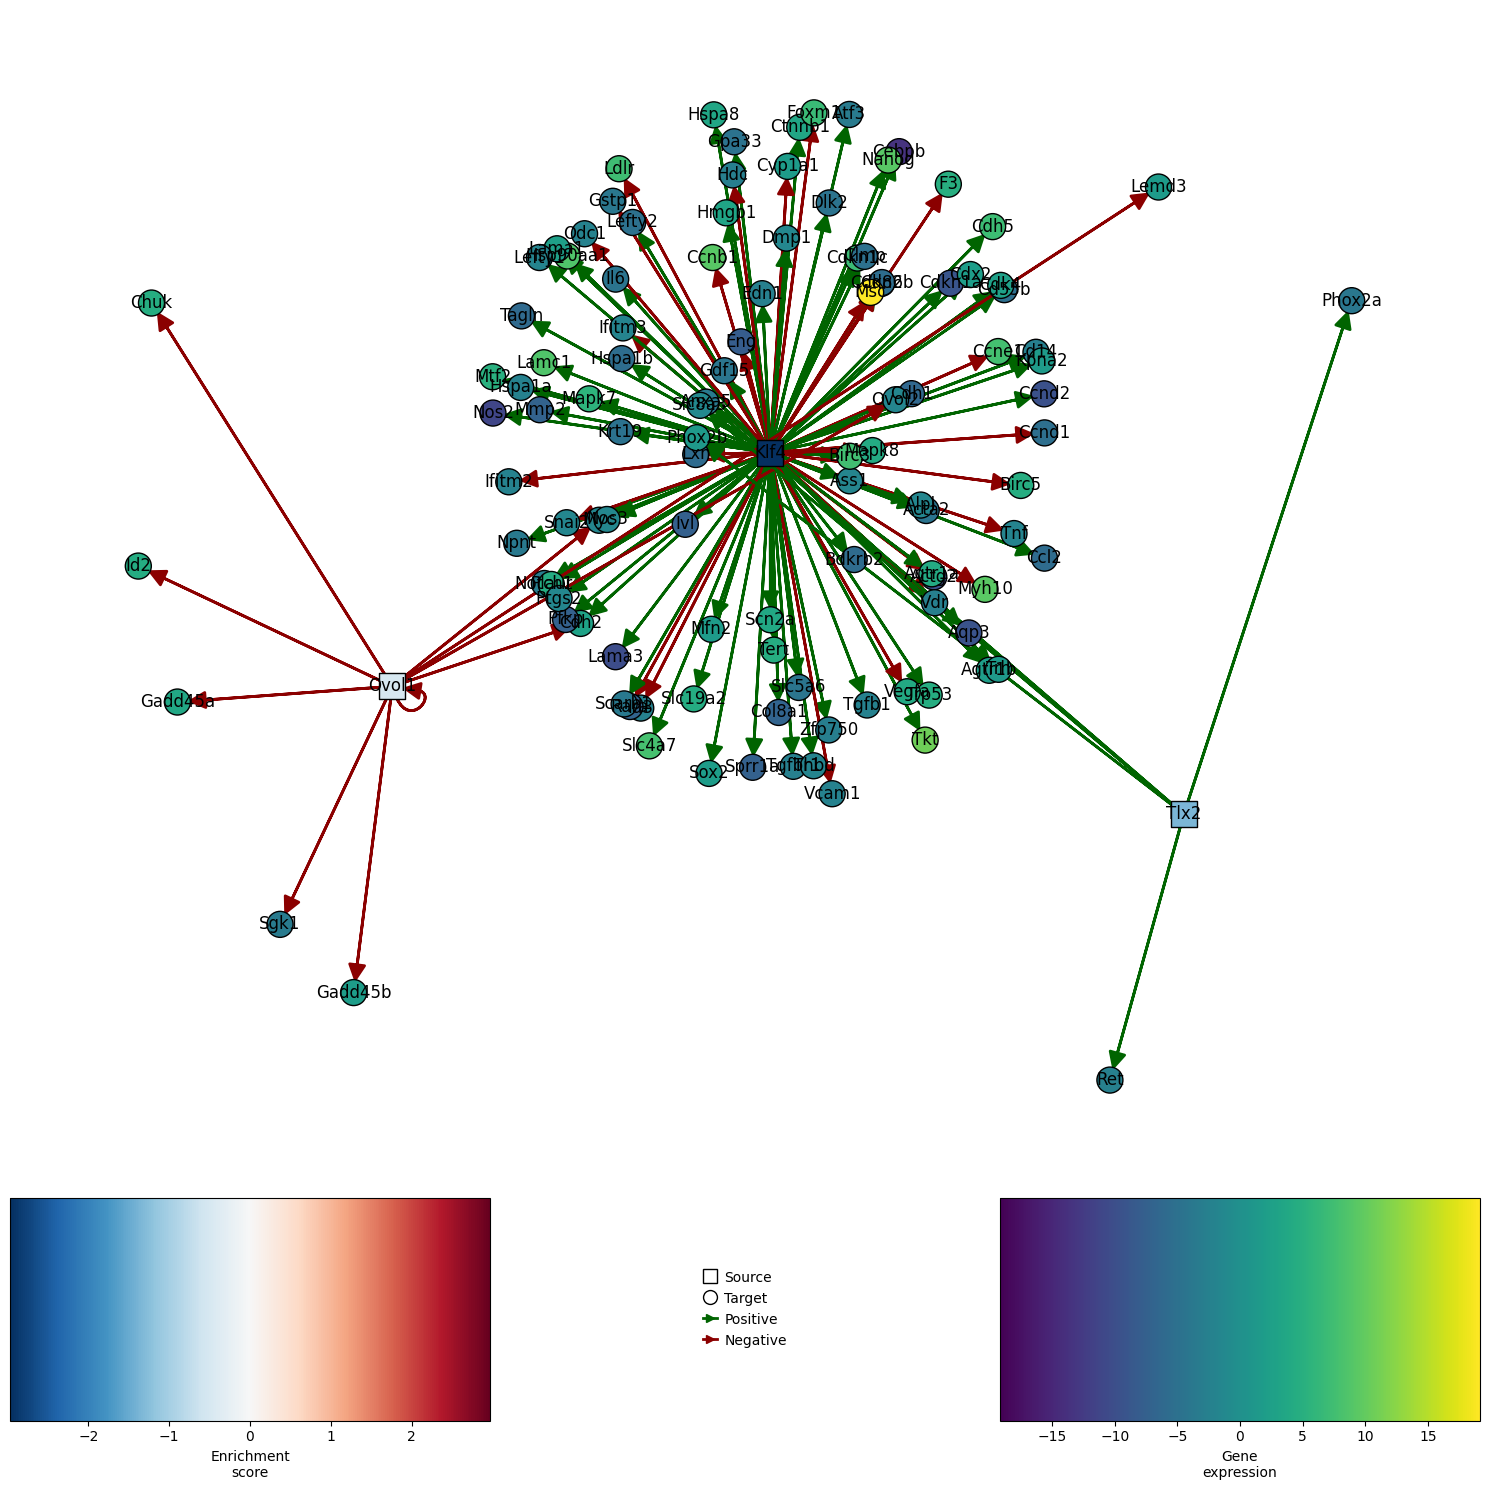

In [30]:
# Plot dead end network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

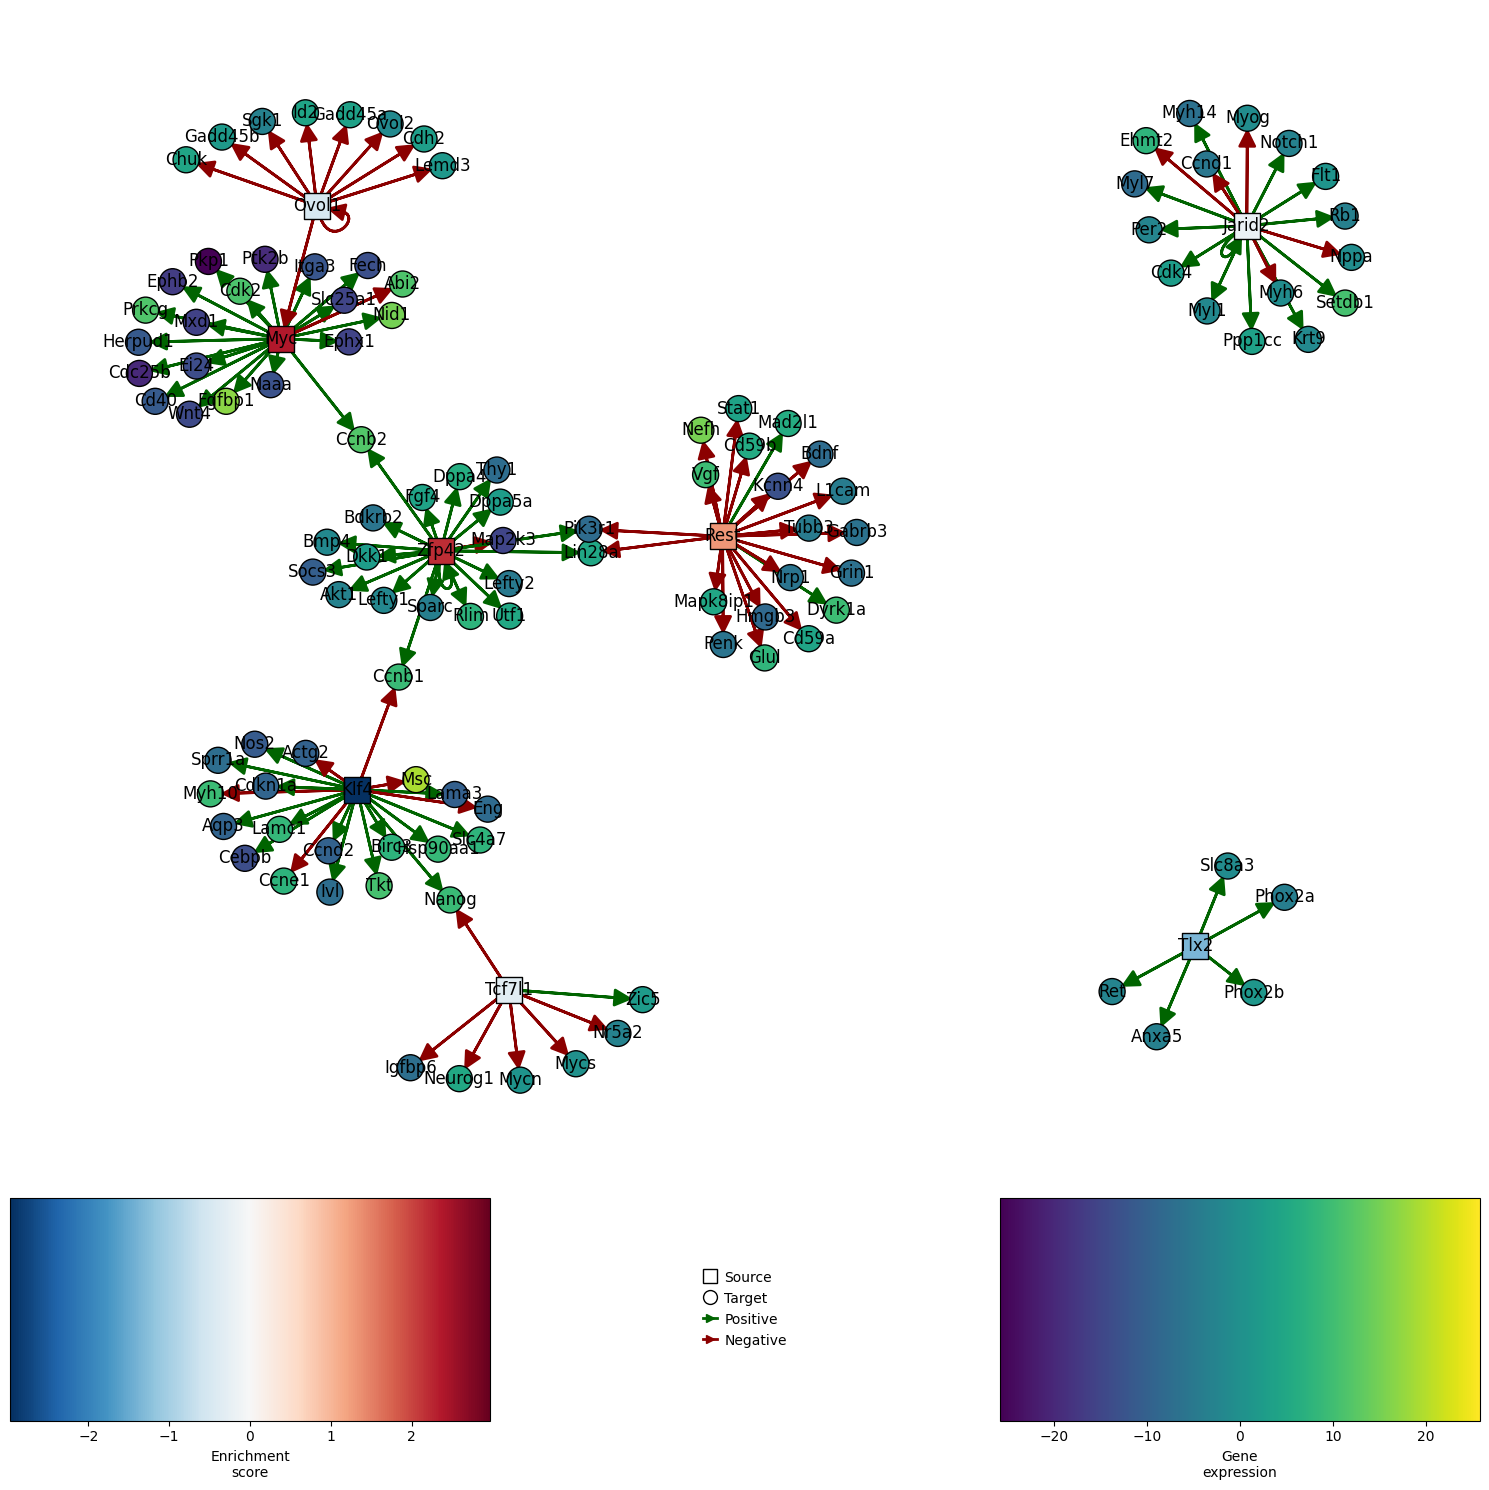

In [31]:
# Network with genes of interest

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=genes_of_interest,
    targets=20,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

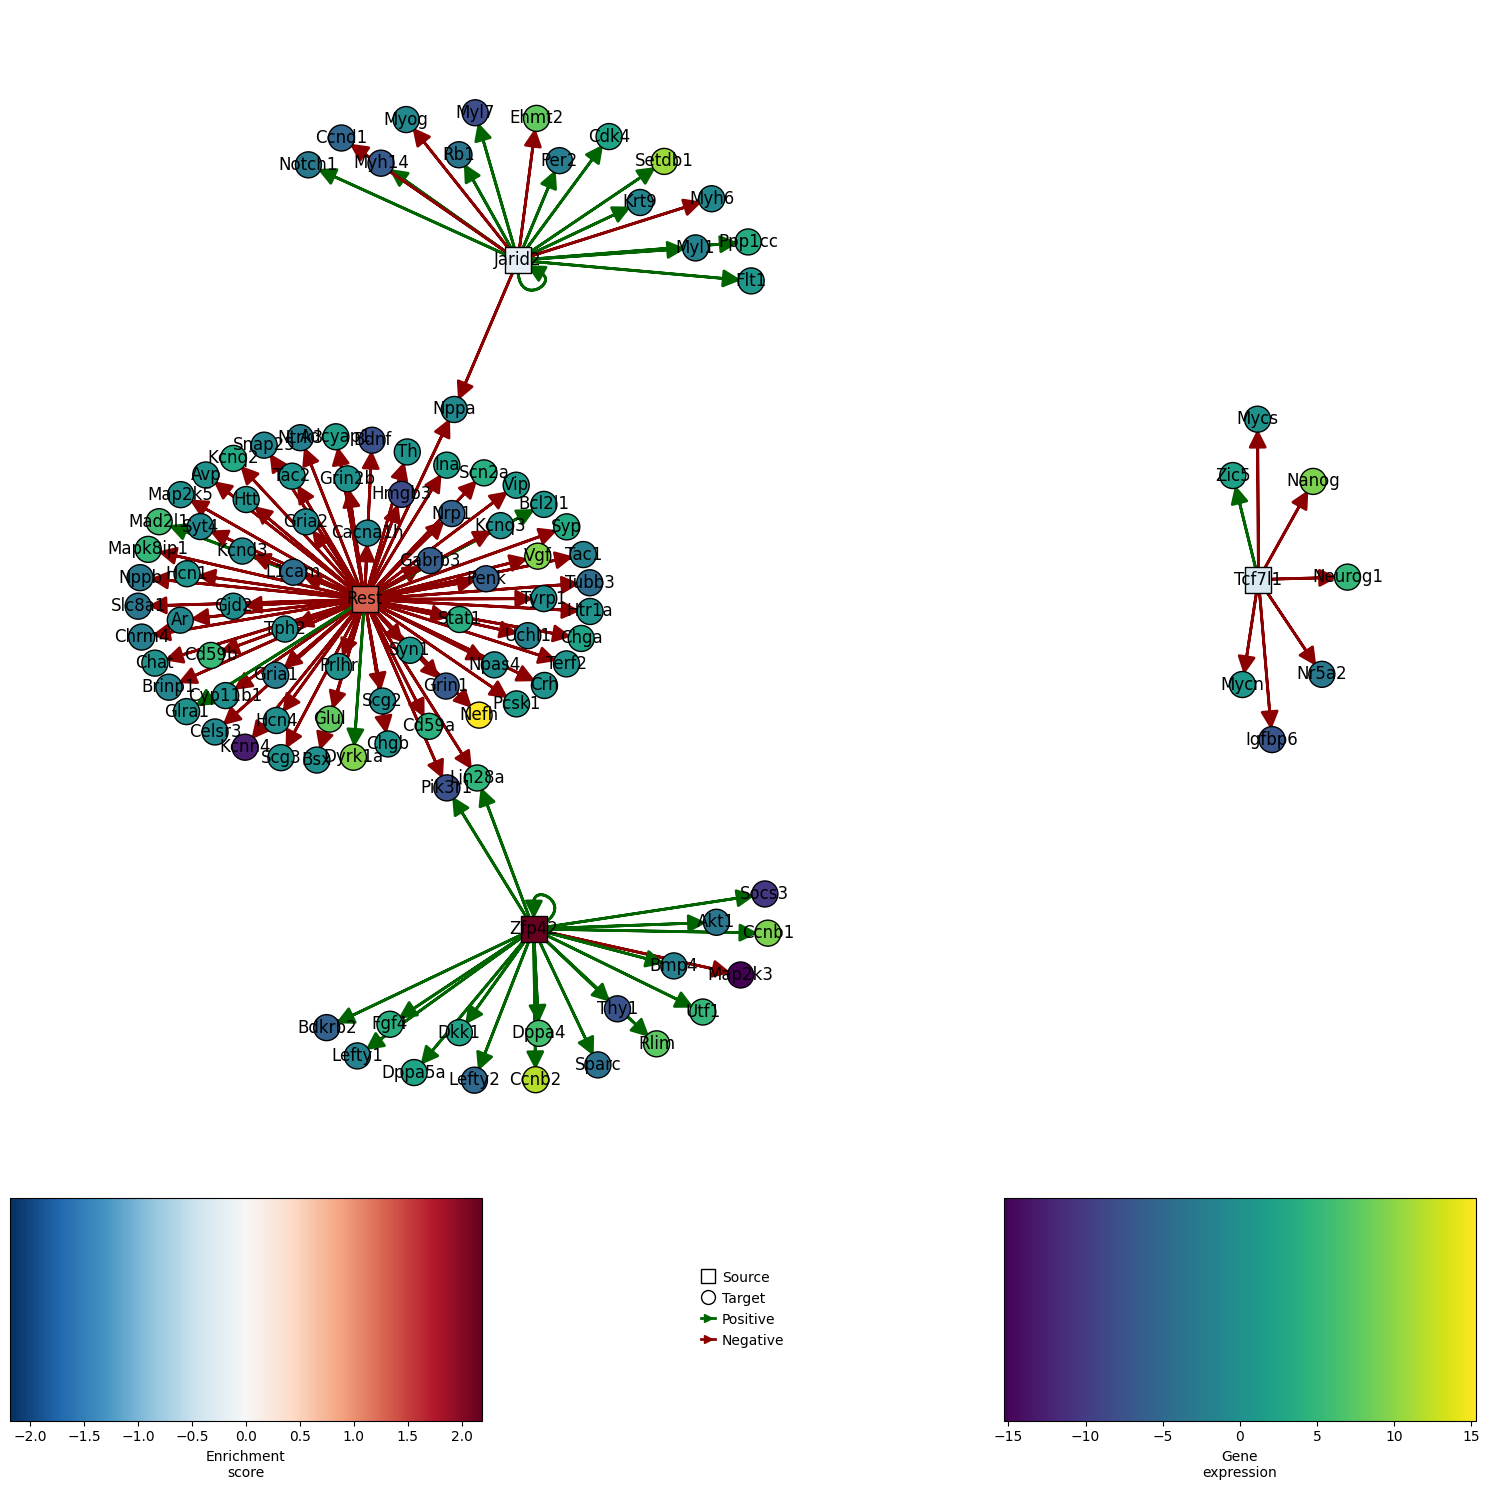

In [32]:
# Plot reprogramming network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=stem_cell_drivers_with_activities,
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

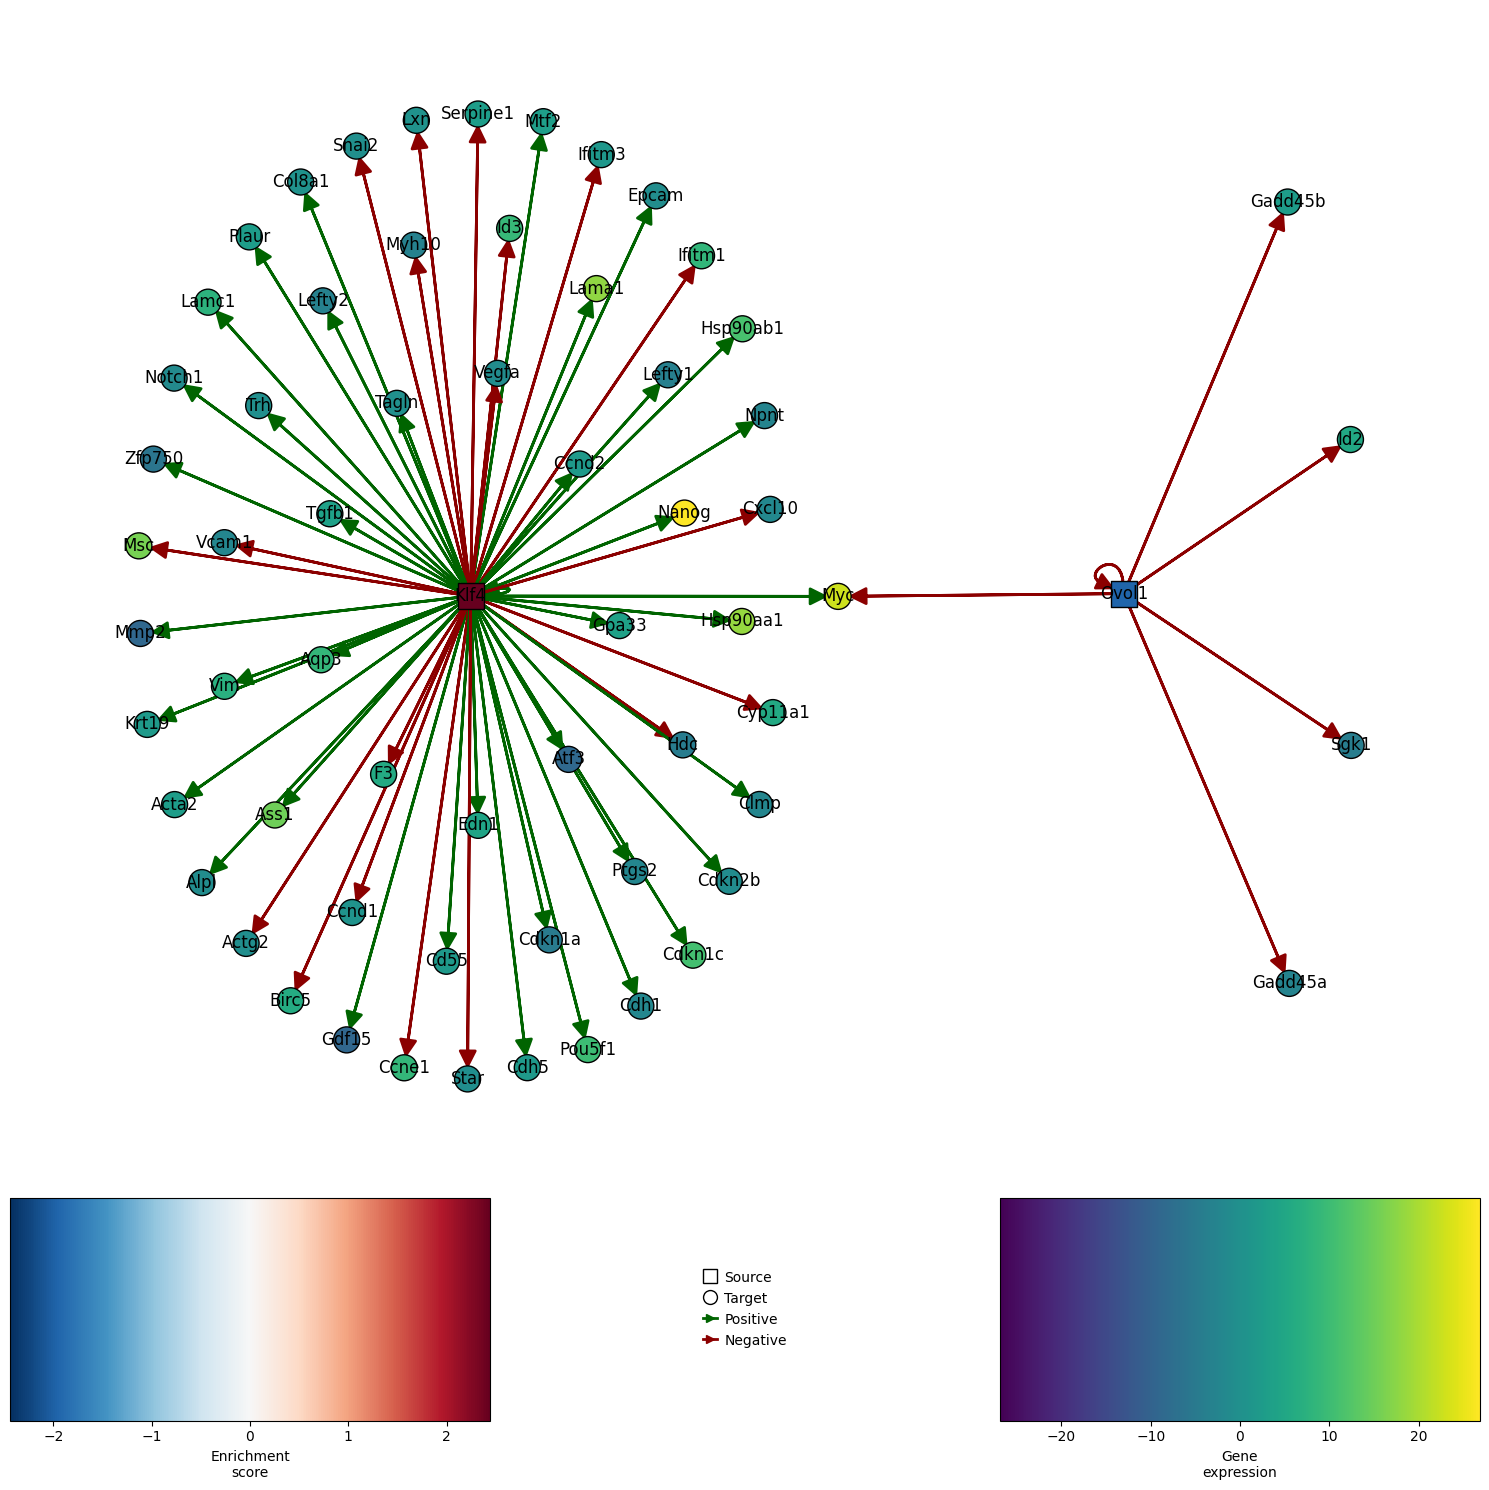

In [33]:
# Plot dead end network for mESCs

data = mesc_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

# Check if velocity for the dead end drivers correlate with Hic2 expression

In [34]:
cell_markers = gseapy.get_library("PanglaoDB_Augmented_2021", organism="Mouse")
epithelial_markers = numpy.array(pandas.Series(cell_markers["Epithelial Cells"]).str.capitalize())
keratinocyte_markers = numpy.array(pandas.Series(cell_markers["Keratinocytes"]).str.capitalize())
stem_cell_markers = numpy.array(pandas.Series(cell_markers["Pluripotent Stem Cells"]).str.capitalize())

2026-03-09 13:22:11 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-09 13:22:11 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.PanglaoDB_Augmented_2021.gmt, use local file


In [35]:
# Keratinocyte markers among dead end drivers

numpy.intersect1d(keratinocyte_markers, dead_end_drivers)

array(['Anxa8', 'Krt13', 'Krt14', 'Krt17', 'Lad1', 'Lgals7', 'Ovol1',
       'Perp', 'Pkp1', 'S100a14'], dtype=object)

In [36]:
# Epithelial markers among dead end drivers

numpy.intersect1d(epithelial_markers, dead_end_drivers)

array(['Crb3', 'Dgat2', 'Gpx2', 'Krt13', 'Krt14', 'Krt8', 'Lad1', 'Mal2',
       'Misp', 'Ovol1', 'Rab25', 'S100a14'], dtype=object)

In [37]:
# Keratinocyte markers among Hic2 targets

numpy.intersect1d(keratinocyte_markers, hic2_targets)

array(['Anxa8', 'Aqp3', 'B3gnt3', 'Cblc', 'Ccl2', 'Dmkn', 'Dsc3',
       'Duoxa1', 'Ehf', 'Entpd2', 'Evpl', 'Fam83b', 'Fgfbp1', 'Foxn1',
       'Fst', 'Fxyd3', 'Gjb3', 'Gjb4', 'Gjb5', 'Icam1', 'Irf3', 'Itgb4',
       'Klf5', 'Klk8', 'Krt13', 'Krt16', 'Krt80', 'Krt84', 'Krtdap',
       'Lad1', 'Lama5', 'Lamc2', 'Lgals7', 'Mst1r', 'Nectin4', 'Ngfr',
       'Ovol1', 'Perp', 'Pkp1', 'Plec', 'Ppp1r13l', 'S100a14', 'S100a2',
       'Sbsn', 'Scel', 'Sfn', 'Slurp1', 'Sprr1a', 'Syt8', 'Tgm1', 'Tns4',
       'Trim29'], dtype=object)

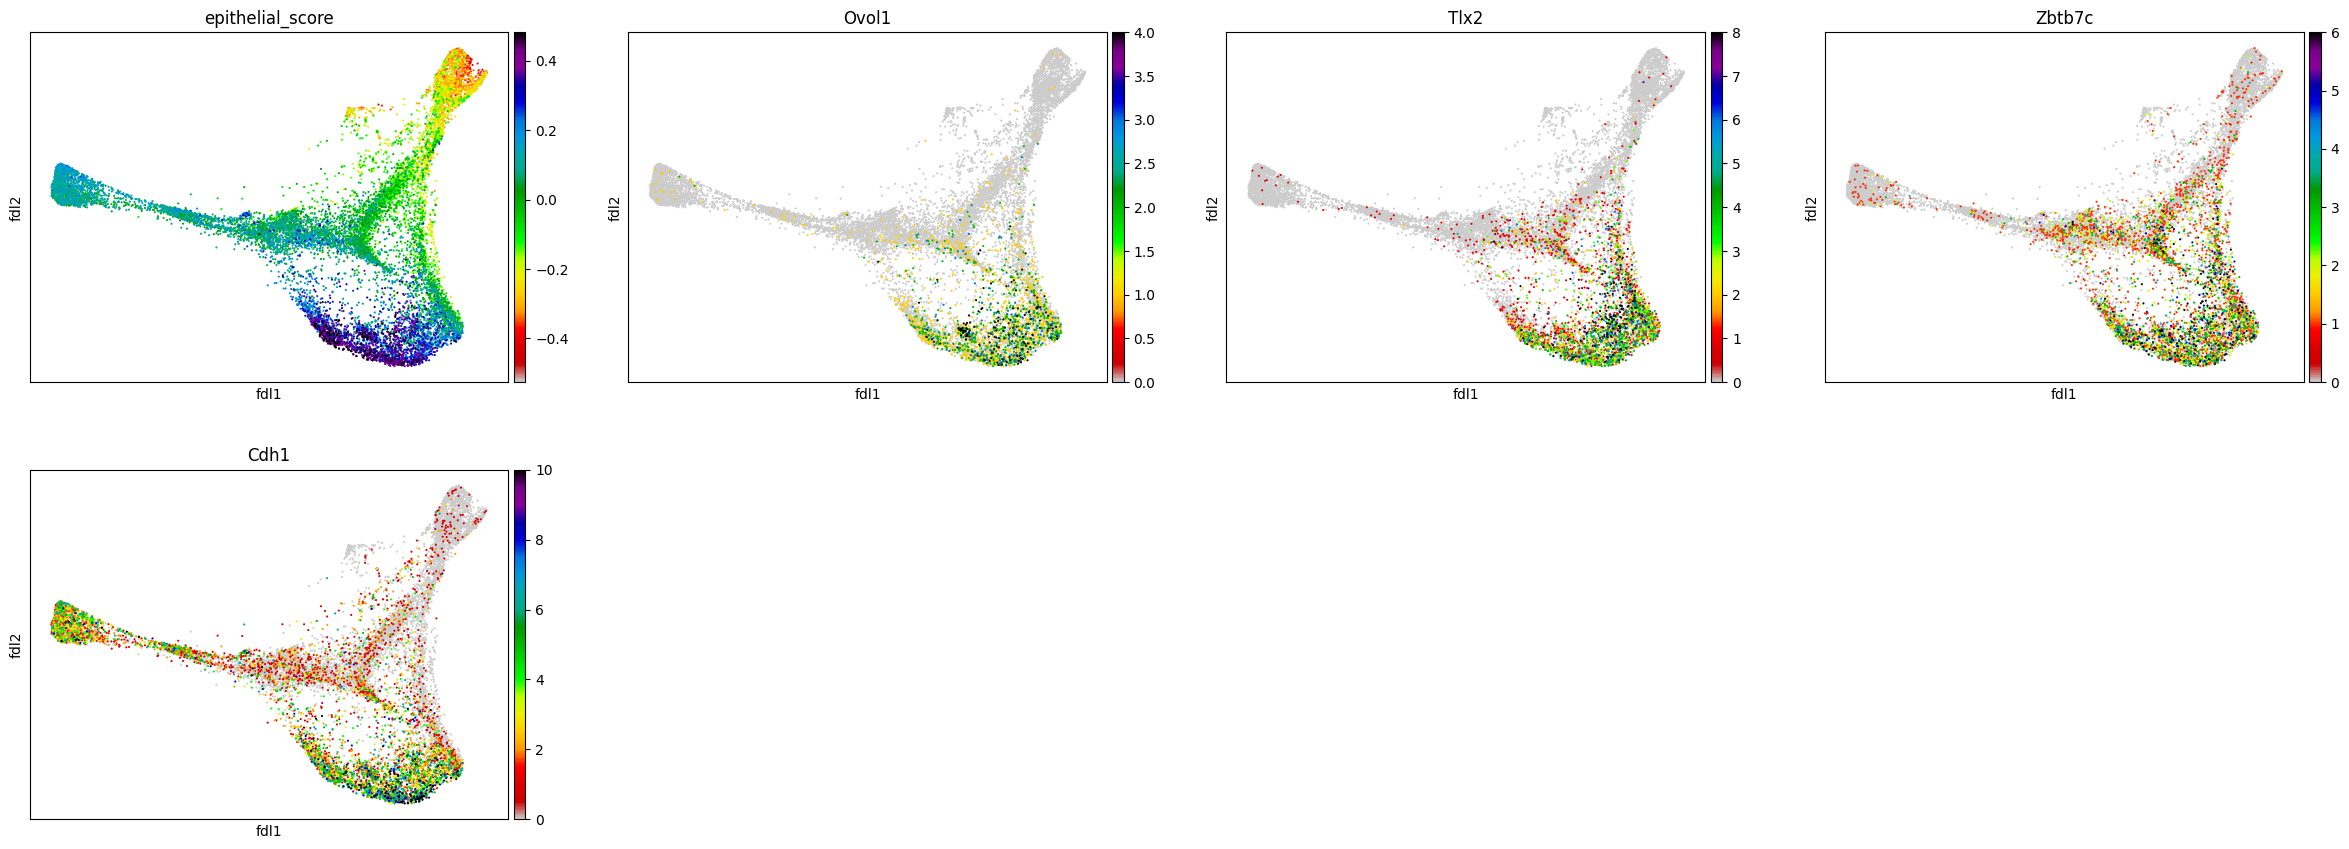

In [46]:
# Plot where epithelial genes are found

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(epithelial_markers, adata.var_names),
    score_name="epithelial_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["epithelial_score"] + de_dead_end_drivers.tolist() + ["Cdh1"],
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

In [39]:
# # Plot where epithelial genes are found, AUCell

# expression_dataframe = pandas.DataFrame(data=adata.layers["spliced"].todense(), index=adata.obs.index, columns=adata.var_names)
# # aucell_rankings = aucell.create_rankings(expression_dataframe)
# aucell_results = aucell.aucell(expression_dataframe, {"epithelial": epithelial_markers})
# aucell_results

In [40]:
collectri_df.query("source == \"Ovol1\" and weight==-1")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,-1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,-1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,-1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,-1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,-1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,-1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,-1.0,ExTRI,20463035,default activation


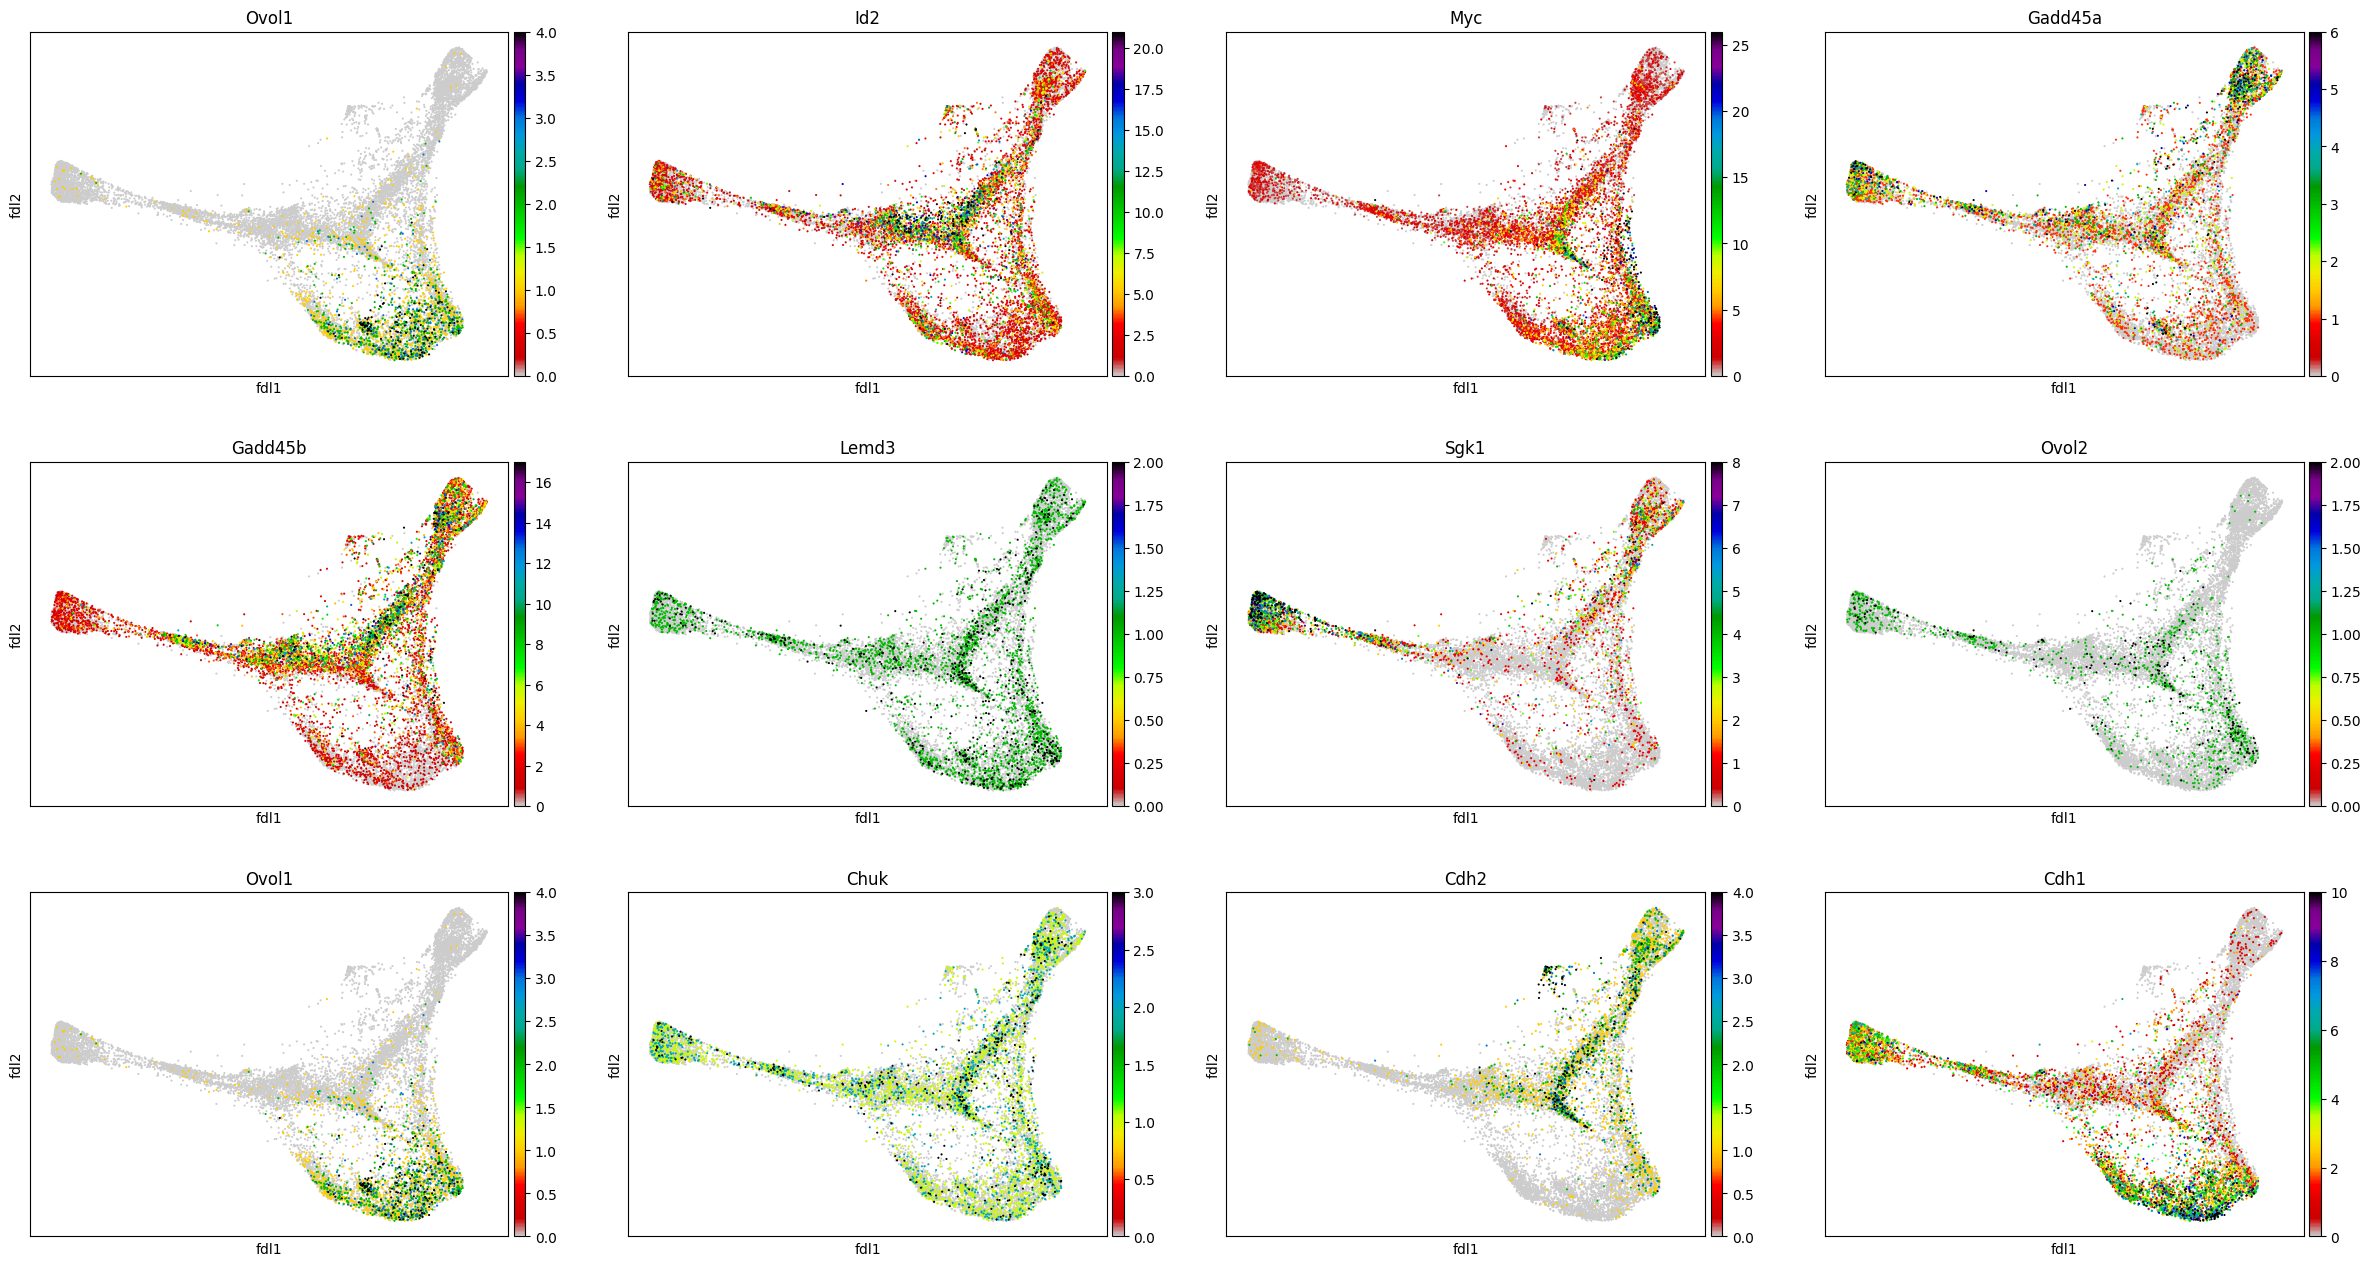

In [42]:
# Expression of Ovol1 targets and Cdh1

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["Ovol1"] + collectri_df.query("source == \"Ovol1\"")["target"].to_list() + ["Cdh1"],
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

Most targets appear to be anticorrelated with Ovol1. Ovol1 is mainly a repressor. The weights of +1 are all assigned by default, so it is likely that most or all targets are actually repressed by Ovol1. Thus, the absence of Ovol1 targets in the control trajectory is additional evidence for Ovol1 activity being higher. Even Ovol2 and Sgk1, which upregulated in control, are absent in the part with high Ovol1 expression.

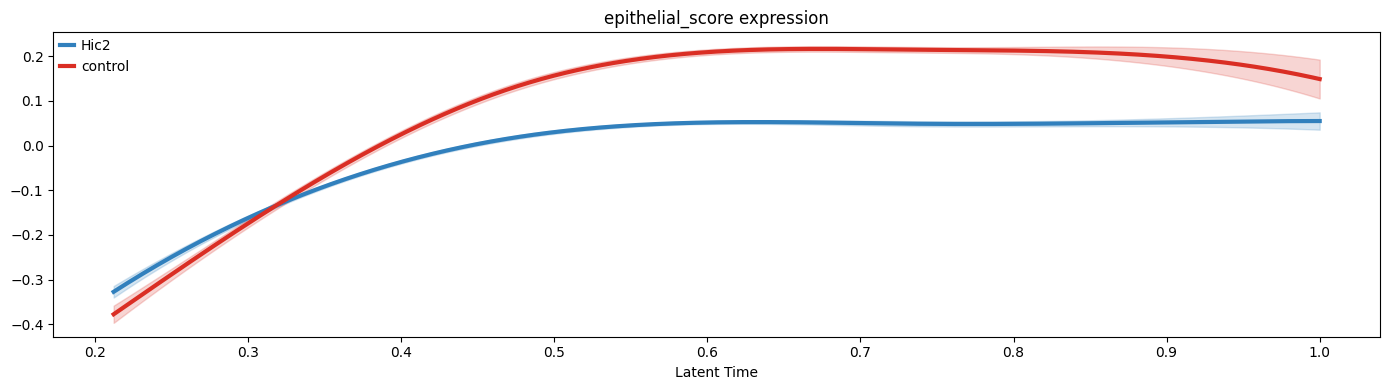

In [ ]:
plot_grouped_gene_trend(adata, genes=["epithelial_score"], layer="obs", groups=["Hic2", "control"])


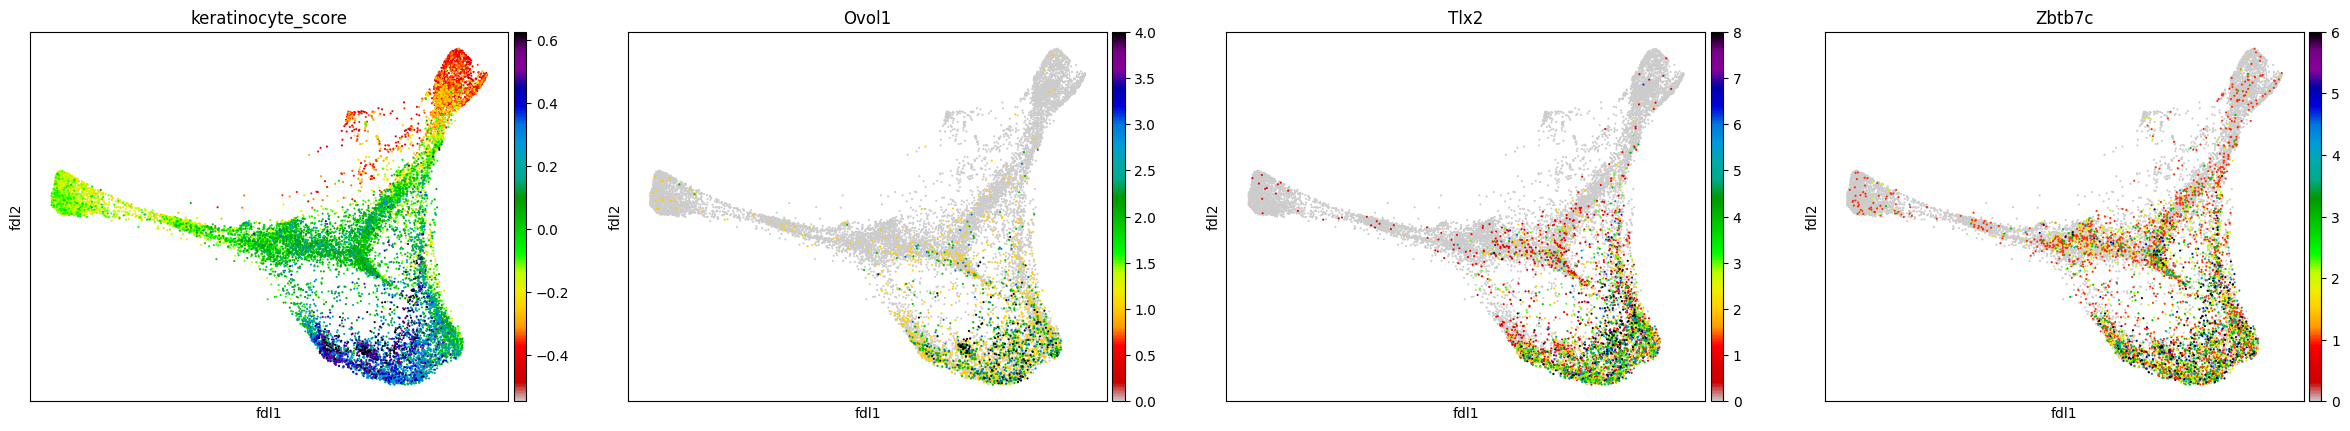

In [ ]:
# Plot where keratinocyte genes are found

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(keratinocyte_markers, adata.var_names),
    score_name="keratinocyte_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["keratinocyte_score"] + de_dead_end_drivers.tolist(),
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

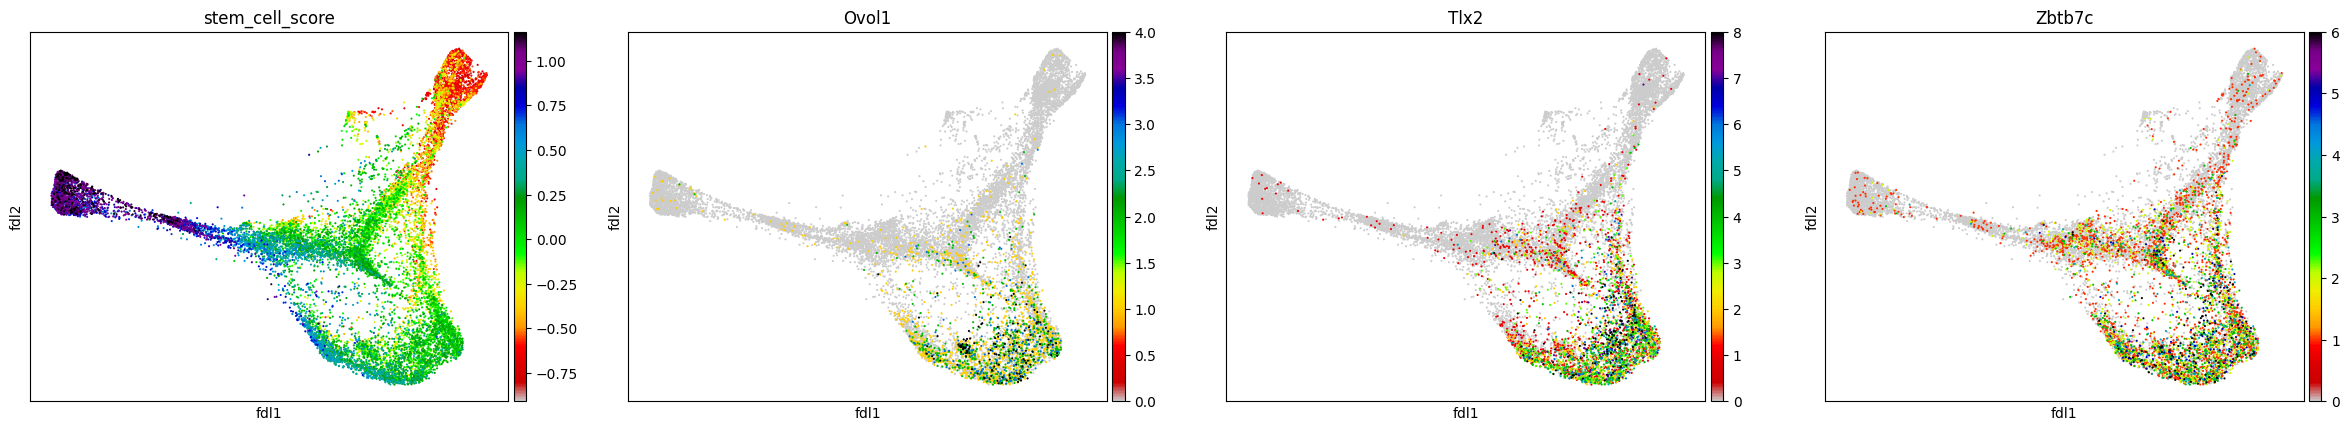

In [ ]:
# Plot where stem cells are found

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(stem_cell_markers, adata.var_names),
    score_name="stem_cell_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["stem_cell_score"] + de_dead_end_drivers.tolist(),
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

In [ ]:
# Find where apoptosis genes are expressed

go_database = gseapy.get_library("GO_Biological_Process_2025", organism="Mouse")
apoptosis_genes = numpy.array(pandas.Series(go_database["Positive Regulation of Apoptotic Process (GO:0043065)"]).str.capitalize())

2026-03-05 10:15:33 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 10:15:33 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-03-05 10:15:33 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [ ]:
msig_database = gseapy.get_library("MSigDB_Hallmark_2020")
apoptosis_genes = numpy.array(pandas.Series(msig_database["Apoptosis"]).str.capitalize())

2026-03-05 10:15:34 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 10:15:34 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


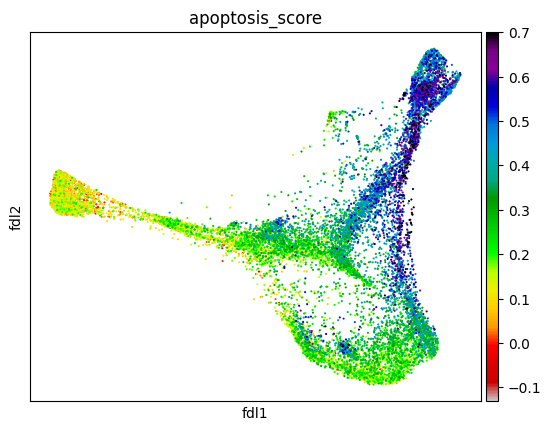

In [ ]:
# Plot where there is apoptosis

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(apoptosis_genes, adata.var_names),
    score_name="apoptosis_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color="apoptosis_score",
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

# Correlations in cells

In [ ]:
def calculate_correlation(adata, variable_1, variable_2, group_key="group", groups=["control", "Hic2"], layers=["Ms", "Ms"], print_results=True, method="spearman"):
    if print_results:
        print(f"Correlation between {variable_1} and {variable_2}")
    if method == "spearman":
        correlation_method = scipy.stats.spearmanr
    elif method == "pearson":
        correlation_method = scipy.stats.pearsonr
    results_dict = {}
    for group in groups:
        indices = adata.obs[group_key] == group
        if variable_1 in adata.obs.columns:
            array_1 = adata[indices].obs[variable_1]
        else:
            array_1 = numpy.array(adata[indices, variable_1].layers[layers[0]])
        if variable_2 in adata.obs.columns:
            array_2 = adata[indices].obs[variable_2]
        else:
            array_2 = numpy.array(adata[indices, variable_2].layers[layers[1]])
        correlation_result = correlation_method(array_1, array_2)
        if isinstance(correlation_result.statistic, numpy.ndarray):
            statistic = correlation_result.statistic[0]
        else:
            statistic = correlation_result.statistic
        if isinstance(correlation_result.pvalue, numpy.ndarray):
            pvalue = correlation_result.pvalue[0]
        else:
            pvalue = correlation_result.pvalue
        if print_results:
            print(f"{group}: {statistic:.3g}, p-value: {pvalue:.3g}")
        else:
            results_dict[group] = {"statistic": statistic, "pvalue": pvalue}
    
    # Total correlation
    if len(groups) > 1:
        indices = adata.obs[group_key].isin(groups)
        if variable_1 in adata.obs.columns:
            array_1 = adata[indices].obs[variable_1]
        else:
            array_1 = numpy.array(adata[indices, variable_1].layers[layers[0]])
        if variable_2 in adata.obs.columns:
            array_2 = adata[indices].obs[variable_2]
        else:
            array_2 = numpy.array(adata[indices, variable_2].layers[layers[1]])
        correlation_result = correlation_method(array_1, array_2)
        if isinstance(correlation_result.statistic, numpy.ndarray):
            statistic = correlation_result.statistic[0]
        else:
            statistic = correlation_result.statistic
        if isinstance(correlation_result.pvalue, numpy.ndarray):
            pvalue = correlation_result.pvalue[0]
        else:
            pvalue = correlation_result.pvalue
        if print_results:
            print(f"Total: {statistic:.3g}, p-value: {pvalue:.3g}")
        else:
            results_dict["total"] = {"statistic": statistic, "pvalue": pvalue}
    if not print_results:
        return results_dict

In [ ]:
# Ovol1 and Myc
calculate_correlation(adata, "Ovol1", "Myc")

Correlation between Ovol1 and Myc
control: 0.455, p-value: 3.53e-255
Hic2: 0.442, p-value: 5.12e-216
Total: 0.587, p-value: 0


In [ ]:
# Hic2 and Myc
calculate_correlation(adata, "Hic2", "Myc")

Correlation between Hic2 and Myc
control: 0.307, p-value: 3.11e-110
Hic2: 0.421, p-value: 9.08e-195
Total: 0.097, p-value: 1.95e-21


In [ ]:
# Ovol1 and epithelial identity
calculate_correlation(adata, "Ovol1", "epithelial_score")

Correlation between Ovol1 and epithelial_score
control: 0.727, p-value: 0
Hic2: 0.352, p-value: 2.1e-132
Total: 0.705, p-value: 0


Supports the idea that Ovol1 contributes to the epithelial identity.

In [ ]:
# Ovol1 and stem cell identity
calculate_correlation(adata, "Ovol1", "stem_cell_score")

Correlation between Ovol1 and stem_cell_score
control: 0.276, p-value: 1.45e-88
Hic2: 0.207, p-value: 6.77e-45
Total: 0.189, p-value: 3.03e-77


In [ ]:
# Hic2 and stem cell identity
calculate_correlation(adata, "Hic2", "stem_cell_score")

Correlation between Hic2 and stem_cell_score
control: 0.501, p-value: 0
Hic2: 0.233, p-value: 8.43e-57
Total: 0.366, p-value: 3.94e-300


In [ ]:
# Ovol1 and Hic2
calculate_correlation(adata, "Hic2", "Ovol1")

Correlation between Hic2 and Ovol1
control: 0.173, p-value: 7.73e-35
Hic2: -0.0217, p-value: 0.144
Total: -0.259, p-value: 8.77e-146


In [ ]:
# Epithelial identity and Hic2
calculate_correlation(adata, "Hic2", "epithelial_score")

Correlation between Hic2 and epithelial_score
control: 0.406, p-value: 1.9e-198
Hic2: 0.125, p-value: 3.73e-17
Total: 0.0454, p-value: 9.15e-06


Epithelial control cells probably upregulate Hic2

In [ ]:
# Hic2 and Ovol1 velocity
calculate_correlation(adata, "Hic2", "Ovol1", layers=["Ms", "sde_velocity"])

Correlation between Hic2 and Ovol1
control: -0.219, p-value: 1.97e-55
Hic2: 0.0544, p-value: 0.000246
Total: -0.259, p-value: 8.77e-146


In [ ]:
# Hic2 and Myc velocity
calculate_correlation(adata, "Hic2", "Myc", layers=["Ms", "sde_velocity"])

Correlation between Hic2 and Myc
control: -0.296, p-value: 2.21e-102
Hic2: -0.397, p-value: 1.59e-171
Total: 0.097, p-value: 1.95e-21


In [ ]:
# Hic2 and Myc velocity
r = calculate_correlation(adata, "Hic2", "Myc", layers=["Ms", "sde_velocity"], print_results=False)

In [ ]:
# Correlation between Hic2 and velocities of all TFs
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
for tf in numpy.intersect1d(target_tfs, adata.var_names):
    results = calculate_correlation(adata, "Hic2", tf, layers=["Ms", "sde_velocity"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

velocity_correlations_df = pandas.DataFrame(index=numpy.intersect1d(target_tfs, adata.var_names))
velocity_correlations_df["control_corr"] = control_correlations
velocity_correlations_df["control_p_value"] = control_correlations_p
velocity_correlations_df["hic2_corr"] = hic2_correlations
velocity_correlations_df["hic2_p_value"] = hic2_correlations_p
velocity_correlations_df["total_corr"] = total_correlations
velocity_correlations_df["total_p_value"] = total_correlations_p

In [ ]:
# Velocity most anticorrelated with Hic2 expression in total

velocity_correlations_df.sort_values("total_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Tfap2c,-0.619523,0.000000e+00,-0.218142,5.253094e-50,-0.431693,0.000000e+00
Hic2,-0.085250,1.451410e-09,-0.473261,4.905598e-252,-0.396939,0.000000e+00
Klf10,-0.334432,1.929562e-131,-0.402449,2.920161e-176,-0.393098,0.000000e+00
Mycn,-0.498302,0.000000e+00,-0.102042,5.603091e-12,-0.366394,1.791195e-301
Id2,-0.224606,1.965377e-58,-0.179022,5.503339e-34,-0.334749,6.259582e-249
Msc,0.098352,2.876533e-12,0.066870,6.545248e-06,-0.323602,7.750983e-232
Stat2,-0.189245,1.076487e-41,-0.305210,1.979245e-98,-0.318695,1.539594e-224
Fosb,-0.393771,7.377986e-186,-0.162767,2.615383e-28,-0.316996,4.815426e-222
Pou5f1,-0.461938,7.106792e-264,-0.418121,1.659815e-191,-0.264817,4.264986e-153
Peg3,-0.302043,2.146823e-106,-0.157803,1.094305e-26,-0.237609,9.064082e-123


In [ ]:
# Velocity most anticorrelated with Hic2 expression in control

velocity_correlations_df.sort_values("control_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Tfap2c,-0.619523,0.000000e+00,-0.218142,5.253094e-50,-0.431693,0.000000e+00
Mycn,-0.498302,0.000000e+00,-0.102042,5.603091e-12,-0.366394,1.791195e-301
Pou5f1,-0.461938,7.106792e-264,-0.418121,1.659815e-191,-0.264817,4.264986e-153
Fosb,-0.393771,7.377986e-186,-0.162767,2.615383e-28,-0.316996,4.815426e-222
Ehf,-0.349003,9.553846e-144,0.105057,1.302391e-12,0.031087,2.370417e-03
Barx2,-0.345615,7.957463e-141,-0.004718,7.507008e-01,0.153795,1.141339e-51
Klf10,-0.334432,1.929562e-131,-0.402449,2.920161e-176,-0.393098,0.000000e+00
Peg3,-0.302043,2.146823e-106,-0.157803,1.094305e-26,-0.237609,9.064082e-123
Arid3a,-0.300448,3.060937e-105,-0.071804,1.289202e-06,-0.155002,1.827529e-52
Myc,-0.296453,2.207916e-102,-0.397404,1.586878e-171,-0.089703,1.551039e-18


Ovol1 is on the list, along with Myc, Klf10 and Arid3a.

In [ ]:
# How strongly they correlate with dead end fate probability

driver_df.loc[velocity_correlations_df.sort_values("control_corr").head(30).index.to_list()][["mESC_corr"]]

,mESC_corr
gene_names,
Tfap2c,0.266078
Mycn,0.327301
Pou5f1,-0.025833
Fosb,0.093258
Ehf,-0.120376
Barx2,-0.218176
Klf10,-0.216327
Peg3,0.194655
Arid3a,-0.033448


In [ ]:
# Velocity most anticorrelated with Hic2 expression in Hic2 OX

velocity_correlations_df.sort_values("hic2_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Hic2,-0.085250,1.451410e-09,-0.473261,4.905598e-252,-0.396939,0.000000e+00
Pou5f1,-0.461938,7.106792e-264,-0.418121,1.659815e-191,-0.264817,4.264986e-153
Klf10,-0.334432,1.929562e-131,-0.402449,2.920161e-176,-0.393098,0.000000e+00
Myc,-0.296453,2.207916e-102,-0.397404,1.586878e-171,-0.089703,1.551039e-18
Klf4,-0.258888,1.105263e-77,-0.390048,9.114427e-165,-0.145360,2.734579e-46
Zmiz1,-0.088422,3.483131e-10,-0.338528,4.796826e-122,-0.127297,8.076555e-36
Stat2,-0.189245,1.076487e-41,-0.305210,1.979245e-98,-0.318695,1.539594e-224
Egr1,-0.217768,5.923772e-55,-0.289642,2.109432e-88,-0.111399,8.951865e-28
Gata6,0.120135,1.335158e-17,-0.256894,2.690182e-69,-0.151209,5.498297e-50
Tcf7l2,-0.168477,2.790192e-33,-0.227490,2.429702e-54,-0.183623,3.031386e-73


Hic2 is on top, suggesting negative feedback on its own expression.

In [ ]:
# Correlation between Hic2 and spliced counts of all TFs
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
for tf in numpy.intersect1d(target_tfs, adata.var_names):
    results = calculate_correlation(adata, "Hic2", tf, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"].statistic)
    control_correlations_p.append(results["control"].pvalue)
    hic2_correlations.append(results["Hic2"].statistic)
    hic2_correlations_p.append(results["Hic2"].pvalue)
    total_correlations.append(results["total"].statistic)
    total_correlations_p.append(results["total"].pvalue)

counts_correlations_df = pandas.DataFrame(index=numpy.intersect1d(target_tfs, adata.var_names))
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

In [ ]:
# Most anticorrelated with Hic2 expression in total
counts_correlations_df.sort_values("total_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Hoxa7,-0.495111,8.534166e-309,-0.321908,6.852993e-110,-0.556234,0.000000e+00
Nfix,-0.445889,7.325760e-244,-0.183386,1.318133e-35,-0.407080,0.000000e+00
Tlx2,-0.060754,1.651411e-05,-0.166291,1.715388e-29,-0.398000,0.000000e+00
Prrx1,-0.495371,3.624721e-309,-0.201087,1.320440e-42,-0.374487,0.000000e+00
Nr2f1,-0.301961,2.462030e-106,-0.162494,3.220785e-28,-0.341532,1.101581e-259
Gata2,-0.079034,2.057861e-08,-0.051758,4.872619e-04,-0.315240,1.754288e-219
Atf5,-0.486726,5.728708e-297,-0.231847,1.980493e-56,-0.307476,2.305166e-208
Junb,-0.195597,1.786421e-44,-0.118612,1.096741e-15,-0.296788,1.333037e-193
Twist1,-0.516317,0.000000e+00,-0.163430,1.573221e-28,-0.287523,2.630986e-181
Ovol1,0.172520,7.732267e-35,-0.021697,1.439555e-01,-0.258553,8.766786e-146


In [ ]:
# Most anticorrelated with Hic2 expression in control
counts_correlations_df.sort_values("control_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Twist1,-0.516317,0.000000e+00,-0.163430,1.573221e-28,-0.287523,2.630986e-181
Prrx1,-0.495371,3.624721e-309,-0.201087,1.320440e-42,-0.374487,0.000000e+00
Hoxa7,-0.495111,8.534166e-309,-0.321908,6.852993e-110,-0.556234,0.000000e+00
Atf5,-0.486726,5.728708e-297,-0.231847,1.980493e-56,-0.307476,2.305166e-208
Irx1,-0.453904,1.010733e-253,-0.190456,2.549652e-38,-0.251426,1.047758e-137
Nfix,-0.445889,7.325760e-244,-0.183386,1.318133e-35,-0.407080,0.000000e+00
En1,-0.405332,7.513334e-198,-0.053089,3.469238e-04,-0.212144,1.094424e-97
Zeb2,-0.398813,4.966204e-191,0.032009,3.108470e-02,-0.159765,1.146087e-55
Zfp503,-0.341935,1.075768e-137,-0.140133,2.466497e-21,-0.206516,1.456686e-92
Nfil3,-0.316269,5.170960e-117,0.008612,5.619526e-01,-0.173084,3.663914e-65


In [ ]:
# Most anticorrelated with Hic2 expression in Hic2 OX
counts_correlations_df.sort_values("hic2_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Hoxa7,-0.495111,8.534166e-309,-0.321908,6.852993e-110,-0.556234,0.000000e+00
Atf5,-0.486726,5.728708e-297,-0.231847,1.980493e-56,-0.307476,2.305166e-208
Id3,-0.247409,6.755191e-71,-0.228380,9.171780e-55,-0.112875,1.780779e-28
Prrx1,-0.495371,3.624721e-309,-0.201087,1.320440e-42,-0.374487,0.000000e+00
Irx1,-0.453904,1.010733e-253,-0.190456,2.549652e-38,-0.251426,1.047758e-137
Nfix,-0.445889,7.325760e-244,-0.183386,1.318133e-35,-0.407080,0.000000e+00
Tlx2,-0.060754,1.651411e-05,-0.166291,1.715388e-29,-0.398000,0.000000e+00
Twist1,-0.516317,0.000000e+00,-0.163430,1.573221e-28,-0.287523,2.630986e-181
Nr2f1,-0.301961,2.462030e-106,-0.162494,3.220785e-28,-0.341532,1.101581e-259
Dbp,0.053314,1.573831e-04,-0.149517,4.268475e-24,0.054886,7.917060e-08


In [ ]:
calculate_correlation(adata, "Klf4", "Klf4", layers=["Ms", "sde_velocity"])

Correlation between Klf4 and Klf4
control: -0.997, p-value: 0
Hic2: -0.994, p-value: 0
Total: -0.997, p-value: 0


In [ ]:
calculate_correlation(adata, "Myc", "Myc", layers=["Ms", "sde_velocity"])

Correlation between Myc and Myc
control: -0.99, p-value: 0
Hic2: -0.956, p-value: 0
Total: -0.978, p-value: 0


In [ ]:
calculate_correlation(adata, "Hic2", "Hic2", layers=["Ms", "sde_velocity"])

Correlation between Hic2 and Hic2
control: -0.0853, p-value: 1.45e-09
Hic2: -0.473, p-value: 4.91e-252
Total: -0.397, p-value: 0


In [ ]:
calculate_correlation(adata, "Ovol1", "Ovol1", layers=["Ms", "sde_velocity"])

Correlation between Ovol1 and Ovol1
control: -0.828, p-value: 0
Hic2: -0.874, p-value: 0
Total: -0.881, p-value: 0


Most genes appear to have very high anticorrelation with their own expression, meaning that the correlation with velocity is often the same as anticorrelation with counts.

In [ ]:
# How Hic2 affects Ovol1

gene = "Ovol1"
print("Velocity correlation:")
IPython.display.display(velocity_correlations_df.loc[[gene]])
print("Counts correlation:")
IPython.display.display(counts_correlations_df.loc[[gene]])

Velocity correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Ovol1,-0.218722,1.968859e-55,0.054403,0.000246,0.196,2.187140e-83


Counts correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Ovol1,0.17252,7.732267e-35,-0.021697,0.143956,-0.258553,8.766786e-146


The control results is more important since Ovol1 counts is very low in Hic2 OX. Velocity suggests that Ovol1 is inhibited by Hic2. The positive correlation in control could be because Hic2 levels are not sufficient to downregulate Ovol1. Hic2 is upregulated in the dead end path for some reason.

In [ ]:
# How Hic2 affects Tlx2

gene = "Tlx2"
print("Velocity correlation:")
IPython.display.display(velocity_correlations_df.loc[[gene]])
print("Counts correlation:")
IPython.display.display(counts_correlations_df.loc[[gene]])

Velocity correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Tlx2,0.061591,0.000013,0.166291,1.715388e-29,0.398203,0.0


Counts correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Tlx2,-0.060754,0.000017,-0.166291,1.715388e-29,-0.398,0.0


Positive correlation, but basically opposite to counts correlation.

In [ ]:
# How Hic2 affects Zbtb7c

gene = "Zbtb7c"
print("Velocity correlation:")
IPython.display.display(velocity_correlations_df.loc[[gene]])
print("Counts correlation:")
IPython.display.display(counts_correlations_df.loc[[gene]])

Velocity correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Zbtb7c,-0.167821,4.951899e-33,-0.119828,5.575510e-16,0.098676,4.088034e-22


Counts correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Zbtb7c,0.345109,2.154961e-140,0.270622,5.526810e-77,-0.091515,3.126485e-19


In [ ]:
# How Hic2 affects Myc

gene = "Myc"
print("Velocity correlation:")
IPython.display.display(velocity_correlations_df.loc[[gene]])
print("Counts correlation:")
IPython.display.display(counts_correlations_df.loc[[gene]])

Velocity correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Myc,-0.296453,2.207916e-102,-0.397404,1.586878e-171,-0.089703,1.551039e-18


Counts correlation:


,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Myc,0.307279,3.108419e-110,0.421368,9.075364e-195,0.097041,1.945015e-21


In [ ]:
# Pearson correlation between Hic2 and Klf4

gene = "Klf4"
print("Velocity\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "sde_velocity"], method="pearson")
print()
calculate_correlation(adata, gene, "Hic2", layers = ["Ms", "sde_velocity"], method="pearson")
print("\nCounts\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "Ms"], method="pearson")

Velocity

Correlation between Hic2 and Klf4
control: -0.474, p-value: 8.2e-280
Hic2: -0.583, p-value: 0
Total: -0.461, p-value: 0

Correlation between Klf4 and Hic2
control: -0.421, p-value: 3.09e-215
Hic2: -0.488, p-value: 8.29e-270
Total: -0.41, p-value: 0

Counts

Correlation between Hic2 and Klf4
control: 0.473, p-value: 0
Hic2: 0.583, p-value: 0
Total: 0.461, p-value: 0


In [ ]:
# Pearson correlation between Hic2 and Ovol1

gene = "Ovol1"
print("Velocity\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "sde_velocity"], method="pearson")
print()
calculate_correlation(adata, gene, "Hic2", layers = ["Ms", "sde_velocity"], method="pearson")
print("\nCounts\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "Ms"], method="pearson")

Velocity

Correlation between Hic2 and Ovol1
control: -0.00944, p-value: 0.504
Hic2: 0.0163, p-value: 0.273
Total: 0.0955, p-value: 7.98e-21

Correlation between Ovol1 and Hic2
control: 0.0737, p-value: 1.69e-07
Hic2: 0.031, p-value: 0.0367
Total: 0.126, p-value: 2.88e-35

Counts

Correlation between Hic2 and Ovol1
control: -0.0254, p-value: 0.0718
Hic2: -0.0246, p-value: 0.0972
Total: -0.148, p-value: 0


In [ ]:
# Pearson correlation between Hic2 and Tlx2

gene = "Tlx2"
print("Velocity\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "sde_velocity"], method="pearson")
print()
calculate_correlation(adata, gene, "Hic2", layers = ["Ms", "sde_velocity"], method="pearson")
print("\nCounts\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "Ms"], method="pearson")

Velocity

Correlation between Hic2 and Tlx2
control: 0.149, p-value: 2.69e-26
Hic2: 0.0882, p-value: 2.64e-09
Total: 0.25, p-value: 1.65e-136

Correlation between Tlx2 and Hic2
control: 0.146, p-value: 3.3e-25
Hic2: 0.0282, p-value: 0.0572
Total: 0.179, p-value: 6.77e-70

Counts

Correlation between Hic2 and Tlx2
control: -0.149, p-value: 3.47e-26
Hic2: -0.0882, p-value: 2.64e-09
Total: -0.25, p-value: 0


In [ ]:
# Correlation between Hic2 and Zbtb7c

gene = "Zbtb7c"
print("Velocity\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "sde_velocity"])
print()
calculate_correlation(adata, gene, "Hic2", layers = ["Ms", "sde_velocity"])
print("\nCounts\n")
calculate_correlation(adata, "Hic2", gene, layers = ["Ms", "Ms"])

Velocity

Correlation between Hic2 and Zbtb7c
control: -0.168, p-value: 4.95e-33
Hic2: -0.12, p-value: 5.58e-16
Total: 0.0987, p-value: 4.09e-22

Correlation between Zbtb7c and Hic2
control: 0.13, p-value: 2.53e-20
Hic2: -0.198, p-value: 2.23e-41
Total: 0.166, p-value: 2.41e-60

Counts

Correlation between Hic2 and Zbtb7c
control: 0.345, p-value: 2.15e-140
Hic2: 0.271, p-value: 5.53e-77
Total: -0.0915, p-value: 3.13e-19


In [ ]:
# Correlation between Ovol1 and its targets
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
gene = "Ovol1"
for tf in numpy.intersect1d(ovol1_targets, adata.var_names):
    results = calculate_correlation(adata, gene, tf, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

ovol1_correlations_df = pandas.DataFrame(index=numpy.intersect1d(ovol1_targets, adata.var_names))
ovol1_correlations_df["control_corr"] = control_correlations
ovol1_correlations_df["control_p_value"] = control_correlations_p
ovol1_correlations_df["hic2_corr"] = hic2_correlations
ovol1_correlations_df["hic2_p_value"] = hic2_correlations_p
ovol1_correlations_df["total_corr"] = total_correlations
ovol1_correlations_df["total_p_value"] = total_correlations_p
ovol1_correlations_df

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Gadd45a,-0.260186,1.796358e-78,-0.194599,5.832667e-40,-0.381916,0.000000e+00
Gadd45b,-0.624629,0.000000e+00,-0.482339,4.084346e-263,-0.731068,0.000000e+00
Id2,-0.254604,4.137909e-75,0.116549,3.404501e-15,-0.294679,9.224584e-191
Myc,0.455070,3.530954e-255,0.441691,5.119344e-216,0.587448,0.000000e+00
Ovol1,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00
Sgk1,-0.709293,0.000000e+00,-0.367884,2.022243e-145,-0.532852,0.000000e+00


In control cells and overall, there is anticorrelation with all targets except Ovol1 itself and Myc. This confirms that these are repressed by Ovol1